# 📘 Loan Approval Data Analysis - Fully Documented

This notebook walks through a complete, well-documented Exploratory Data Analysis (EDA) pipeline for the Loan Approval dataset.

We structure the analysis into five main sections:

    1. Data Loading and Initial Exploration

    2. Data Summary and Statistics

    3. Data Cleaning and Preprocessing

    4. Feature Engineering

    5. Data Visualization

## Environment Setup & Dataset Upload

In [1]:
# Upload the dataset from  local machine
from google.colab import files
uploaded = files.upload()

Saving LoanData.csv to LoanData.csv


In [2]:
# Import core libraries to use throughout the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Configure pandas display options for clarity
pd.set_option('display.max_columns', None)

## 1.Data Loading and Initial Exploration

### 1.1 Load CSV into a DataFrame

In [5]:
import io
df = pd.read_csv(io.BytesIO(uploaded['LoanData.csv']))

### 1.2 Peek at the first few rows ("Printing rows of the Data")

In [6]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### 1.3 Dataset shape and index

In [7]:
print("Number of columns:", df.shape[1])
print("Number of observations (rows):", df.shape[0])
print("Index info:", df.index)
print("\nColumn names:")
print(df.columns.tolist())

Number of columns: 13
Number of observations (rows): 614
Index info: RangeIndex(start=0, stop=614, step=1)

Column names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


## 1.4 Quick look at the tail & random sample

In [8]:
# Last 5 rows
df.tail()

# Random 5 rows for a quick sense of variability
df.sample(5, random_state=42)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
350,LP002139,Male,Yes,0,Graduate,No,9083,0.0,228.0,360.0,1.0,Semiurban,Y
377,LP002223,Male,Yes,0,Graduate,No,4310,0.0,130.0,360.0,NaN,Semiurban,Y
163,LP001570,Male,Yes,2,Graduate,No,4167,1447.0,158.0,360.0,1.0,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
132,LP001478,Male,No,0,Graduate,No,2718,0.0,70.0,360.0,1.0,Semiurban,Y


## 1.5 Basic column-wise null count

In [9]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


## 2.Data Summary and Statistics

### 2.1 DataFrame Info ("Summary of Data Frame")

In [10]:
# Data types, non-null counts, memory footprint
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


### 2.2 Descriptive Statistics ("Descriptive Statistical Measures of a DataFrame")

In [11]:
stats = df.describe(include='all')
stats

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


### 2.3 Separate numeric vs categorical columns

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


## 2.4 Quick frequency tables for key categorical variables

In [13]:
for col in ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed','Property_Area', 'Loan_Status']:
  if col in df.columns:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))


Value counts for Gender:
Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64

Value counts for Married:
Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64

Value counts for Dependents:
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64

Value counts for Education:
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Value counts for Self_Employed:
Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64

Value counts for Property_Area:
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Value counts for Loan_Status:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


## 3.Data Cleaning and Preprocessing

### 3.1 Standardize / fix categorical anomalies

In [14]:
if 'Dependents' in df.columns:
  df['Dependents'] = df['Dependents'].replace('3+', 3)
  df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

### 3.2 Missing Data Handling ("Missing Data Handing")

In [15]:
# Re-check missing values after minor fixes
missing_before = df.isnull().sum().sort_values(ascending=False)
print("Missing values BEFORE imputation:\n", missing_before)

Missing values BEFORE imputation:
 Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Education             0
Loan_ID               0
CoapplicantIncome     0
ApplicantIncome       0
Property_Area         0
Loan_Status           0
dtype: int64


In [16]:
# Example imputation plan tailored to common Loan dataset columns
num_impute_cols = [c for c in ['LoanAmount', 'Loan_Amount_Term'] if c in df.columns]
cat_impute_cols = [c for c in ['Gender', 'Married', 'Dependents', 'Self_Employed','Credit_History', 'Education', 'Property_Area'] if c in df.columns]

In [17]:
# Numeric: median imputation
for col in num_impute_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical: mode imputation
for col in cat_impute_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# If target has NaNs (rare), drop them
if 'Loan_Status' in df.columns:
    df = df.dropna(subset=['Loan_Status'])



In [18]:
# Double-check missing values AFTER imputation
missing_after = df.isnull().sum().sort_values(ascending=False)
print("Missing values AFTER imputation:\n", missing_after)

Missing values AFTER imputation:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


### 3.3 Remove duplicate rows (if any) and reset index

In [19]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Dropped {before - after} duplicate rows. New shape: {df.shape}")

Dropped 0 duplicate rows. New shape: (614, 13)


### 3.4 Sorting DataFrame values ("Sorting DataFrame values")

In [20]:
# Sort by ApplicantIncome (descending) to inspect top earners
if 'ApplicantIncome' in df.columns:
    df_sorted_income = df.sort_values(by='ApplicantIncome', ascending=False)
    df_sorted_income.head()

### 3.5 Merge DataFrames

In [21]:
# Create a dummy DataFrame to demonstrate merge on Loan_ID
if 'Loan_ID' in df.columns:
    extra_df = pd.DataFrame({'Loan_ID': df['Loan_ID'],'Dummy_Score': range(len(df))})
    merged_df = pd.merge(df, extra_df, on='Loan_ID', how='left')
    merged_df.head()

## 4.Feature Engineering

### 4.1 Apply Function – Income Category

In [22]:
# Categorize ApplicantIncome into Low/Medium/High using apply

def income_bucket(x):
      if x < 2500:
        return 'Low'
      elif x < 6000:
        return 'Medium'
      else:
        return 'High'
if 'ApplicantIncome' in df.columns:
      df['Income_Category'] = df['ApplicantIncome'].apply(income_bucket)
      df[['ApplicantIncome', 'Income_Category']].head()

### 4.2 Lambda Operator ("By using the lambda operator") – Shorten Property Area

In [23]:
# Use lambda to extract first letter of Property_Area as a compact category
if 'Property_Area' in df.columns:
    df['Area_Short'] = df['Property_Area'].apply(lambda x: x[0])
    df[['Property_Area', 'Area_Short']].head()

### 4.3 Additional common engineered features for loan datasets

In [24]:
# Total income = ApplicantIncome + CoapplicantIncome
if set(['ApplicantIncome', 'CoapplicantIncome']).issubset(df.columns):
    df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [25]:
# EMI (approx): LoanAmount * 1000 / Loan_Amount_Term
# (Assuming LoanAmount is in thousands, Loan_Amount_Term in months)
if set(['LoanAmount', 'Loan_Amount_Term']).issubset(df.columns):
    df['EMI'] = (df['LoanAmount'] * 1000) / df['Loan_Amount_Term']


In [26]:
# Income to Loan ratio (higher → potentially more risk or vice-versa depending on context)
if set(['TotalIncome', 'LoanAmount']).issubset(df.columns):
    df['Income_to_Loan'] = df['TotalIncome'] / (df['LoanAmount'] * 1000)


In [27]:
# Log transformation for skewed distributions
for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome']:
  if col in df.columns:
      df[f'Log_{col}'] = np.log1p(df[col])

## 5.Data Visualization ("Visualizing DataFrame")

In [37]:
# Seaborn/Matplotlib settings
sns.set(style='whitegrid', context='notebook', palette='Set2')

### 5.1 Target balance – Loan Status countplot

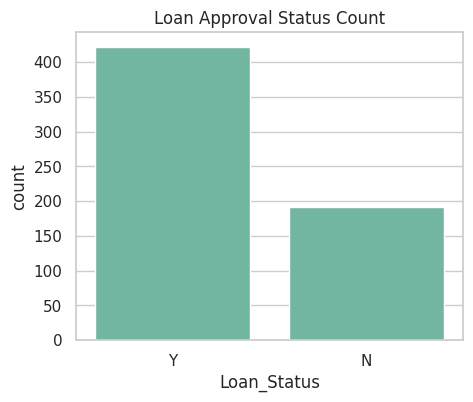

In [38]:
if 'Loan_Status' in df.columns:
    plt.figure(figsize=(5,4))
    sns.countplot(x='Loan_Status', data=df)
    plt.title('Loan Approval Status Count')
    plt.show()

### 5.2 Applicant Income vs Loan Amount colored by Loan Status

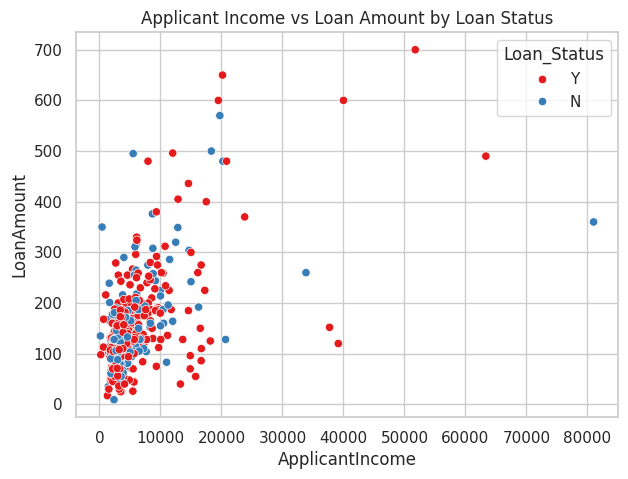

In [39]:
if set(['ApplicantIncome', 'LoanAmount', 'Loan_Status']).issubset(df.columns):
    plt.figure(figsize=(7,5))
    sns.scatterplot(x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', data=df,palette='Set1')
    plt.title('Applicant Income vs Loan Amount by Loan Status')
    plt.show()

### 5.3 Loan Amount distribution

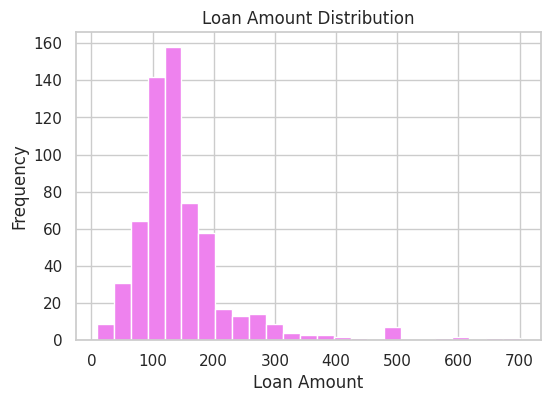

In [44]:
if 'LoanAmount' in df.columns:
    plt.figure(figsize=(6,4))
    df['LoanAmount'].plot.hist(bins=25, color='violet', edgecolor='white')
    plt.title('Loan Amount Distribution')
    plt.xlabel('Loan Amount')
    plt.show()

### 5.4 Property Area vs Loan Status (approval rates by area)

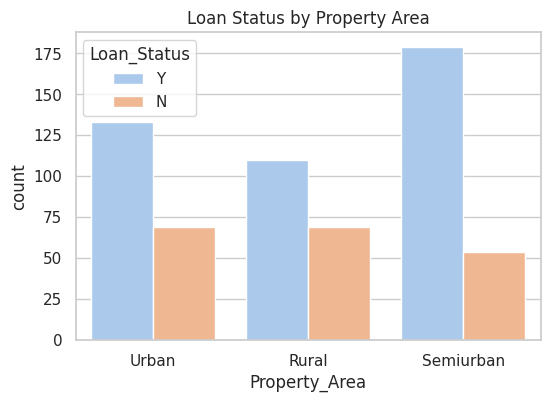

In [45]:
if set(['Property_Area', 'Loan_Status']).issubset(df.columns):
    plt.figure(figsize=(6,4))
    sns.countplot(x='Property_Area', hue='Loan_Status', data=df , palette='pastel')
    plt.title('Loan Status by Property Area')
    plt.show()

### 5.5 Credit History vs Loan Status

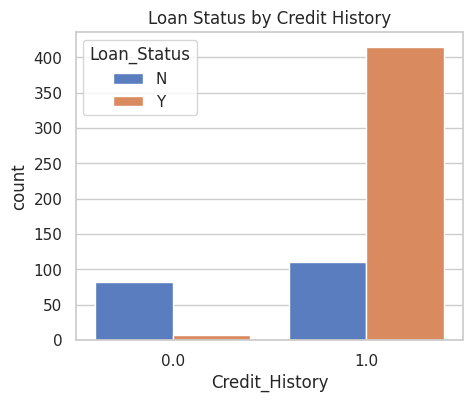

In [46]:
if set(['Credit_History', 'Loan_Status']).issubset(df.columns):
    plt.figure(figsize=(5,4))
    sns.countplot(x='Credit_History', hue='Loan_Status', data=df , palette='muted')
    plt.title('Loan Status by Credit History')
    plt.show()

# 🔚 Conclusion
Through this detailed EDA process, we gained a strong understanding of the structure and quality of the loan approval dataset. By exploring missing values, engineering meaningful features, and visualizing key insights, we are now well-positioned to proceed with predictive modeling. The patterns revealed—especially around credit history, income levels, and property area—can provide valuable signals for loan approval classification models.